# Patient Risk Classification - Classification Track Part A (Review 1)
**Project**: Healthcare Cost Prediction and Patient Risk Intelligence Platform
**Track**: Classification Part A (Target: `is_high_risk`)
**Academic Year**: 2026-27 | 23CSE301 Machine Learning - Capstone Project

### Project Overview & Objectives
In this notebook, we implement the **Classification Track Part A** to identify patients at high risk of elevated healthcare costs. We train, evaluate, and compare 5 classifiers (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM). We perform hyperparameter tuning using RandomizedSearchCV, construct the confusion matrix and ROC-AUC curves, and save the best classifier.

## 1. Setup and Environment
We import all necessary libraries and load global configurations.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)

## 2. Preprocessing & Stratified Train/Test Split
We load the dataset, apply feature engineering, and perform a stratified train/test split. We verify that the target class distribution is balanced across the train and test splits.

In [2]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_classification()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nTrain Target Distribution (is_high_risk):')
print(y_train.value_counts(normalize=True))
print('\nTest Target Distribution (is_high_risk):')
print(y_test.value_counts(normalize=True))

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Train Target Distribution (is_high_risk):
is_high_risk
0    0.632188
1    0.367812
Name: proportion, dtype: float64

Test Target Distribution (is_high_risk):
is_high_risk
0    0.6322
1    0.3678
Name: proportion, dtype: float64


## 3. Classifier Model Training (Review 1 Part A)
We train the 5 required classifiers: Logistic Regression, KNN, Naive Bayes (Gaussian), Decision Tree, and SVM. Hyperparameter tuning is performed on Logistic Regression and Decision Tree.

In [3]:
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results = model_training.train_classification(X_train, X_test, y_train, y_test, preprocessor)

Training KNN Classifier (on 8,000 row subsample for speed)...


Training Support Vector Machine (on 8,000 row subsample for speed)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Evaluating Baseline Classification Models:
Logistic Regression            | Acc: 0.9954 | Prec: 0.9973 | Rec: 0.9902 | F1: 0.9954 | AUC: 0.9998


K-Nearest Neighbors            | Acc: 0.8586 | Prec: 0.9133 | Rec: 0.6801 | F1: 0.8531 | AUC: 0.9399
Naive Bayes                    | Acc: 0.8355 | Prec: 0.7816 | Rec: 0.7671 | F1: 0.8352 | AUC: 0.9105
Decision Tree                  | Acc: 0.9977 | Prec: 0.9975 | Rec: 0.9962 | F1: 0.9977 | AUC: 0.9989


...

Best Logistic Regression Params: {'classifier__penalty': 'l2', 'classifier__C': 10.0}


Best Decision Tree Params: {'classifier__min_samples_split': 2, 'classifier__max_depth': None}
Fitting best Logistic Regression on full train set...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting best Decision Tree on full train set...


Best Classifier Model: Tuned Decision Tree saved to /Users/hemachandra/Documents/ML_capstone/models/best_classifier.joblib


## 4. Preliminary Results Comparison
We display the metrics (Accuracy, Precision, Recall, F1, ROC-AUC) for all models on the held-out test split, ranked by F1-Score.

In [4]:
df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Decision Tree,0.9988,0.998640,0.998097,0.998800,0.998653
1,Tuned Logistic Regression,0.9987,0.997827,0.998641,0.998700,0.999754
2,Decision Tree,0.9977,0.997550,0.996194,0.997700,0.998932
3,Logistic Regression,0.9954,0.997262,0.990212,0.995397,0.999757
4,Support Vector Machine,0.9656,0.967471,0.938010,0.965485,0.996215
5,K-Nearest Neighbors,0.8586,0.913290,0.680125,0.853142,0.939874
6,Naive Bayes,0.8355,0.781579,0.767129,0.835173,0.910456


## 5. Best Classifier Performance Diagnostics
We load the best saved classifier, plot the Confusion Matrix, and generate the ROC-AUC curve.

Classification Report for the Best Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12644
           1       1.00      1.00      1.00      7356

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



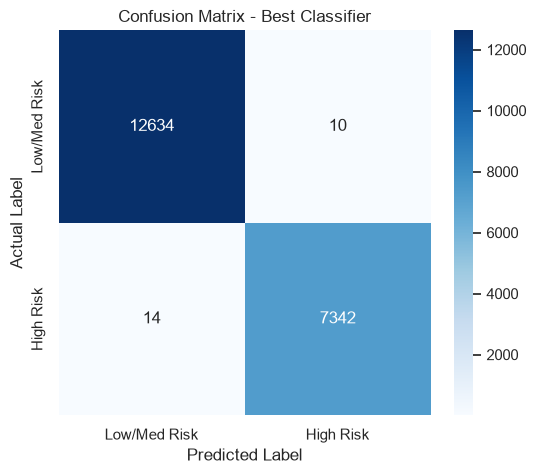

In [5]:
best_clf = joblib.load(config.BEST_CLASSIFIER_PATH)
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]

print('Classification Report for the Best Model:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low/Med Risk', 'High Risk'], yticklabels=['Low/Med Risk', 'High Risk'])
plt.title('Confusion Matrix - Best Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

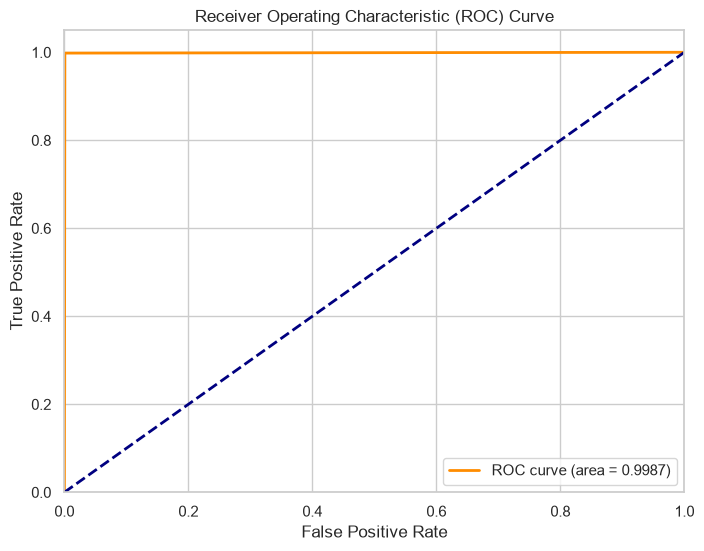

In [6]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()